# Resilient EV Charging Under Disruption

## Technical report notebook for DTU 42578 Advanced Business Analytics

This notebook is the final technical report for the project on resilience in EV charging operations. It is written as a structured report rather than an exploration log. The central question is whether mobile charging stations can be used intelligently to reduce queueing pressure when demand is uneven and charging infrastructure is disrupted.

The intended research question is:

**Can a reinforcement learning policy improve resilience in an EV charging corridor by dynamically reallocating mobile charging stations to reduce queue length and waiting time under disruptions?**

A crucial caveat shapes the report: the current checkout contains the active simulator, the active configs, copied RL training history, and baseline rollout artifacts, but it does **not** contain a current-compatible RL checkpoint or RL rollout artifact for the active 27-feature, 5-action A-B-C benchmark. The report therefore separates three things carefully:

- the **RL formulation**, which can be described precisely,
- the **RL training diagnostics**, which are available from copied training history,
- the **reproducible operational rollout evidence**, which is currently available for the fixed baseline and heuristic adaptive baselines.

The notebook follows this exact structure:

1. Motivation / problem definition  
2. Simulation environment  
3. Simulation design  
4. RL agent and methods  
5. Reward calibration  
6. Training setup  
7. Training the model  
8. Simulation comparison rollout  
9. Summary metrics table  
10. Spatial awareness  
11. Limitations  
12. Conclusion  
13. Appendix


In [2]:

from pathlib import Path
import sys
import os
import subprocess

REPO_ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'exam_submission').exists())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from exam_submission.utils.artifact_finder import artifact_table, missing_notes
from exam_submission.utils.load_artifacts import (
    load_core_configs,
    load_heldout_runs,
    load_reward_sweep_summary,
    load_suite_outputs,
    load_training_history,
)
from exam_submission.utils.plotting import (
    set_report_style,
    plot_corridor_schematic,
    plot_demand_profile,
    plot_training_history,
)
from exam_submission.utils.project_summary import (
    WHAT_MODEL_DOES_NOT_KNOW,
    action_table,
    environment_table,
    expected_daily_profile,
    observation_table,
    reward_table,
)

set_report_style()
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 160)

configs = load_core_configs()
env_cfg = configs['environment']
rl_simple_cfg = configs['rl_simple']
rl_sb3_cfg = configs['rl_sb3']
experiment_cfg = configs['experiment']
heldout_cfg = configs['heldout']
heldout_runs = load_heldout_runs()
reward_sweep = load_reward_sweep_summary()
suite_outputs = load_suite_outputs()
training_history, training_history_source = load_training_history()

daily_profile = expected_daily_profile(env_cfg)
heldout_frames = {name: payload['metrics'] for name, payload in heldout_runs.items()}
heldout_summaries = {name: payload['summary'] for name, payload in heldout_runs.items()}
artifact_df = pd.DataFrame(artifact_table())

MAIN_POLICIES = ['mobile_noop', 'mobile_threshold']
MAIN_POLICY_LABELS = {'mobile_noop': 'Fixed / no-agent', 'mobile_threshold': 'Adaptive threshold'}
MAIN_COLORS = {'mobile_noop': '#4C566A', 'mobile_threshold': '#2A9D8F'}
ALL_POLICY_LABELS = {'mobile_noop': 'Fixed / no-agent', 'mobile_threshold': 'Adaptive threshold', 'mobile_reactive': 'Reactive'}
ALL_COLORS = {'mobile_noop': '#4C566A', 'mobile_threshold': '#2A9D8F', 'mobile_reactive': '#E76F51'}


def _markdown_escape(value):
    return str(value).replace('|', '\\|').replace(chr(10), '<br>')


def _markdown_table(frame, index=False):
    columns = list(frame.columns)
    if index:
        columns = ['index', *columns]
    header = '| ' + ' | '.join(_markdown_escape(col) for col in columns) + ' |'
    divider = '| ' + ' | '.join(['---'] * len(columns)) + ' |'
    rows = []
    for idx, (_, row) in enumerate(frame.iterrows()):
        values = row.tolist()
        if index:
            values = [frame.index[idx], *values]
        rows.append('| ' + ' | '.join(_markdown_escape(value) for value in values) + ' |')
    return chr(10).join([header, divider, *rows])


def show_table(df, precision=2, index=False):
    frame = df.copy()
    numeric_cols = frame.select_dtypes(include='number').columns
    if precision is not None and len(numeric_cols) > 0:
        frame.loc[:, numeric_cols] = frame.loc[:, numeric_cols].round(precision)
    display(Markdown(_markdown_table(frame, index=index)))


def rolling_mean(series, window_steps=12):
    return pd.Series(series).rolling(window_steps, min_periods=1).mean()


def shade_disruptions(ax, frame):
    active = frame['disruption_active'].fillna(0).astype(int).to_numpy()
    hours = frame['global_hour'].to_numpy()
    start = None
    for idx, flag in enumerate(active):
        if flag == 1 and start is None:
            start = hours[idx]
        if flag == 0 and start is not None:
            ax.axvspan(start, hours[idx], color='#F4A261', alpha=0.16)
            start = None
    if start is not None:
        ax.axvspan(start, hours[-1], color='#F4A261', alpha=0.16)


def build_environment_overview_table():
    base = environment_table(env_cfg).copy()
    sim = env_cfg['environment']['simulation']
    chargers = int(env_cfg['environment']['mobile_station_chargers'])
    mean_service = float(sim['service_time']['mean_minutes'])
    vehicles_per_hour = chargers * 60.0 / mean_service
    extra_rows = pd.DataFrame([
        ('Mean MCS throughput', f"{vehicles_per_hour:.1f} vehicles/hour per MCS (~{vehicles_per_hour/12:.2f} vehicles per 5-minute step)"),
        ('Depot-to-station travel', f"{float(env_cfg['environment'].get('mcs_middle_travel_minutes', 30.0)):.0f} minutes"),
        ('Full MCS recharge time', f"{float(env_cfg['environment'].get('mcs_charge_full_minutes', 60.0)):.0f} minutes"),
    ], columns=['Setting', 'Value'])
    return pd.concat([base, extra_rows], ignore_index=True)


def build_simulation_layers_table():
    rows = [
        ('Base corridor', 'Three cities in a line with one fixed station on each link.', 'Creates the minimal spatial setting in which local congestion can differ between AB and BC.'),
        ('Time-varying demand', 'Morning peak, afternoon peak, and a smaller midday bump.', 'Makes congestion depend on time of day rather than a flat average flow.'),
        ('OD structure', 'Trips are split across AB, BA, BC, CB, AC, and CA flows.', 'Allows station pressure to come from directional travel patterns, not only total volume.'),
        ('Queueing and service', 'Vehicles may stop to charge, join queues, and occupy plugs for stochastic service times.', 'Turns traffic into an operational service problem with waiting-time consequences.'),
        ('Mobile charging stations', 'Up to 10 MCS units add flexible but delayed capacity.', 'Creates the control lever that can potentially improve resilience.'),
        ('Disruptions', 'Capacity drops, outages, service-time inflation, and OD demand surges.', 'Creates stress conditions under which resilience can be evaluated directly.'),
    ]
    return pd.DataFrame(rows, columns=['Layer added', 'Implementation', 'Why it matters'])


def build_distribution_table():
    sim = env_cfg['environment']['simulation']
    disruption = sim['disruption']
    rows = [
        ('Expected total traffic', 'Deterministic baseline + Gaussian-shaped morning/evening peaks + midday bump', f"Baseline {sim['traffic']['baseline_cars_per_step']:.0f} cars/step; peak width {sim['traffic']['peak_width_hours']:.1f} h."),
        ('Origin shares', 'Time-varying weighted shares across A, B, and C origins', 'Directional bias shifts origin pressure toward A in the morning and toward C in the evening.'),
        ('Passing vehicles by OD and step', 'Poisson draw around expected OD flow', 'Implements stochastic arrivals around the deterministic demand profile.'),
        ('Charging decision', 'Binomial draw from passing vehicles with fixed stop probability', f"Charging-stop probability = {sim['charging_stop_probability']:.3f}."),
        ('Station assignment', 'Multinomial assignment using OD-specific station weights', 'Long trips can pressure both stations; local trips pressure one side only.'),
        ('Service time', 'Normal draw, then clipped to configured min/max bounds', f"Mean {sim['service_time']['mean_minutes']:.0f} min, std {sim['service_time']['std_minutes']:.0f}, clipped to {sim['service_time']['min_minutes']:.0f}-{sim['service_time']['max_minutes']:.0f} min."),
        ('Disruptions per day', 'Categorical draw from configured day-level count weights', f"Weights: {dict(disruption['day_disruption_count_weights'])}."),
        ('Disruption timing and severity', 'Uniform draws within configured ranges for start time, duration, and severity', 'Keeps disruptions stochastic but bounded and interpretable.'),
    ]
    return pd.DataFrame(rows, columns=['Process', 'Distribution / mechanism', 'Assumption in the active benchmark'])


def build_disruption_table():
    disruption = env_cfg['environment']['simulation']['disruption']
    rows = []
    for key in disruption['event_types']:
        cfg = disruption[key]
        if key == 'capacity_drop':
            severity = f"Target plugs sampled from {cfg['target_num_plugs']}"
        elif key == 'station_outage':
            severity = 'Target station forced to zero plugs'
        elif key == 'service_time_inflation':
            severity = f"Service-time multiplier sampled from {cfg['multiplier']}"
        else:
            severity = f"Demand multiplier sampled from {cfg['multiplier']}"
        rows.append({
            'Type': key.replace('_', ' '),
            'Targets': ', '.join(cfg['targets']),
            'Start window': f"{cfg['start_hour_range'][0]}-{cfg['start_hour_range'][1]} h",
            'Duration': str(cfg['duration_hours']),
            'Severity': severity,
        })
    return pd.DataFrame(rows)


def build_state_group_table():
    rows = [
        ('Queue state', 4, 'Current queue length and current mean wait at AB and BC.'),
        ('Recent flow', 4, 'Latest arrivals and latest service starts at each station.'),
        ('Capacity state', 4, 'Effective plugs and active mobile capacity at AB and BC.'),
        ('Spatial pressure', 4, 'Committed MCS bias and local deficit estimates by side of corridor.'),
        ('Disruption state', 4, 'Whether a disruption is active, what type it is, and which side it affects.'),
        ('MCS logistics', 5, 'Units available in depot, charging, or in transit to AB, BC, or middle.'),
        ('Time-of-day', 2, 'Sine and cosine encodings of time within the day.'),
    ]
    return pd.DataFrame(rows, columns=['Feature group', 'Count', 'Why it is in the state'])


def build_architecture_table():
    simple = rl_simple_cfg['rl']
    sb3 = rl_sb3_cfg['rl']
    hidden = ' → '.join(['27', *[str(v) for v in simple['hidden_dims']], '5'])
    checkpoint_candidates = sorted(REPO_ROOT.glob('**/best_model.pt')) + sorted(REPO_ROOT.glob('**/best_model.zip'))
    checkpoint_note = str(checkpoint_candidates[0].relative_to(REPO_ROOT)) if checkpoint_candidates else 'No current compatible checkpoint found in checkout'
    rows = [
        ('Observation size', 27),
        ('Action size', 5),
        ('Simple learner backend', simple['backend']),
        ('Simple learner network', f"MLP {hidden}"),
        ('Simple learner optimizer', f"Adam, learning rate {simple['learning_rate']}"),
        ('Simple learner TD loss', 'Huber / smooth L1 loss on one-step TD targets'),
        ('SB3 candidate backend', sb3['backend']),
        ('SB3 policy class', 'MlpPolicy with net_arch [256, 256]'),
        ('Current checkpoint status', checkpoint_note),
    ]
    return pd.DataFrame(rows, columns=['Item', 'Value'])


def build_simple_hyperparameter_table():
    simple = rl_simple_cfg['rl']
    rows = [
        ('Episodes', simple['episodes']),
        ('Max steps / episode', simple['max_steps_per_episode']),
        ('Discount factor γ', simple['gamma']),
        ('Learning rate', simple['learning_rate']),
        ('Batch size', simple['batch_size']),
        ('Replay capacity', simple['replay_capacity']),
        ('Learning starts', simple['learning_starts']),
        ('Train frequency', simple['train_frequency']),
        ('Gradient steps', simple['gradient_steps']),
        ('Target update interval', simple['target_update_interval']),
        ('Hidden dimensions', str(simple['hidden_dims'])),
        ('Exploration start ε', simple['epsilon_start']),
        ('Exploration end ε', simple['epsilon_end']),
        ('Exploration decay steps', simple['epsilon_decay_steps']),
        ('Periodic eval cadence', f"Every {simple['eval_interval_steps']} environment steps"),
        ('Periodic eval episodes', simple['eval_during_training_episodes']),
    ]
    return pd.DataFrame(rows, columns=['Simple learner hyperparameter', 'Value'])


def build_sb3_hyperparameter_table():
    sb3 = rl_sb3_cfg['rl']
    sb3_inner = sb3['sb3']
    rows = [
        ('Total timesteps', sb3_inner['total_timesteps']),
        ('Learning rate', sb3['learning_rate']),
        ('Discount factor γ', sb3['gamma']),
        ('Replay buffer', sb3_inner['buffer_size']),
        ('Learning starts', sb3_inner['learning_starts']),
        ('Batch size', sb3_inner['batch_size']),
        ('Train frequency', sb3_inner['train_freq']),
        ('Gradient steps', sb3_inner['gradient_steps']),
        ('Exploration fraction', sb3_inner['exploration_fraction']),
        ('Initial ε', sb3_inner['exploration_initial_eps']),
        ('Final ε', sb3_inner['exploration_final_eps']),
        ('Target update interval', sb3_inner['target_update_interval']),
        ('Evaluation episodes', sb3['evaluation_episodes']),
    ]
    return pd.DataFrame(rows, columns=['SB3 hyperparameter', 'Value'])


def build_reward_term_tables():
    positive = reward_table(env_cfg, positive=True).rename(columns={'Term': 'Positive term', 'Weight': 'Weight', 'Interpretation': 'Operational role'})
    negative = reward_table(env_cfg, positive=False).rename(columns={'Term': 'Negative term', 'Weight': 'Weight', 'Interpretation': 'Operational role'})
    return positive, negative


def build_reward_calibration_table():
    frame = reward_sweep[['run', 'active_mcs_cost', 'queue_penalty', 'final_mean_queue_length', 'final_mean_queue_wait_minutes', 'final_mean_active_mobile_stations', 'final_reward']].copy()
    frame = frame.rename(columns={
        'run': 'Run',
        'active_mcs_cost': 'MCS cost',
        'queue_penalty': 'Queue cost',
        'final_mean_queue_length': 'Mean queue',
        'final_mean_queue_wait_minutes': 'Mean wait',
        'final_mean_active_mobile_stations': 'Mean active MCS',
        'final_reward': 'Final reward',
    })
    return frame.sort_values(['MCS cost', 'Queue cost']).reset_index(drop=True)


def build_training_setup_table():
    simple = rl_simple_cfg['rl']
    rows = [
        ('Training episodes', 'Randomized 2-6 day episodes sampled from training seeds 0-9999.'),
        ('Periodic evaluation', f"{simple['eval_during_training_episodes']} held-out episodes every {simple['eval_interval_steps']} environment steps without exploration or learning updates."),
        ('Validation split', 'Configured held-out validation seeds starting at 10000; useful for policy checks even without hyperparameter tuning.'),
        ('Held-out rollout', 'A fixed unseen `test_id` scenario used for the main time-series comparison in this report.'),
        ('Test stress suite', 'Named one-day scripted disruptions used for robustness checks; kept in the appendix to avoid clutter.'),
    ]
    return pd.DataFrame(rows, columns=['Component', 'How it is used in this report'])


def build_training_status_table():
    history_frame = pd.DataFrame(training_history)
    checkpoint_candidates = sorted(REPO_ROOT.glob('**/best_model.pt')) + sorted(REPO_ROOT.glob('**/best_model.zip'))
    if training_history_source == 'submission_copy':
        source_label = 'Copied current training history in exam_submission/data/generated/training/history_current.json'
    elif training_history_source == 'current_outputs':
        source_label = 'Current outputs/mobile_mcs_line_abc/rl/history.json'
    else:
        source_label = 'Historical fallback artifact'
    rows = [
        ('Training-history source', source_label),
        ('Train reward available', 'Yes' if 'reward' in history_frame else 'No'),
        ('Train TD loss available', 'Yes' if 'loss' in history_frame else 'No'),
        ('Eval reward available', 'Yes' if ('eval_mean_reward' in history_frame and history_frame['eval_mean_reward'].notna().any()) else 'No'),
        ('Eval TD loss available', 'Yes' if ('eval_td_loss' in history_frame and history_frame['eval_td_loss'].notna().any()) else 'No'),
        ('Current compatible checkpoint available', 'Yes' if checkpoint_candidates else 'No'),
    ]
    return pd.DataFrame(rows, columns=['Artifact check', 'Status'])


def build_main_results_table():
    fixed = heldout_frames['mobile_noop']
    adaptive = heldout_frames['mobile_threshold']
    rows = []
    for key, frame in [('mobile_noop', fixed), ('mobile_threshold', adaptive)]:
        rows.append({
            'Policy': MAIN_POLICY_LABELS[key],
            'Mean queue': frame['queue_length'].mean(),
            'Peak queue': frame['queue_length'].max(),
            'Mean wait (min)': frame['queue_wait_mean_minutes'].mean(),
            'Peak wait (min)': frame['queue_wait_mean_minutes'].max(),
            'Breach rate': frame['queue_wait_target_breached'].mean(),
            'Started sessions': frame['starts_total'].sum(),
            'Mean active MCS': frame['num_active_mobile_stations'].mean(),
            'MCS hours': frame['num_active_mobile_stations'].sum() * 5 / 60,
            'Reward': frame['reward'].sum(),
        })
    table = pd.DataFrame(rows)
    fixed_row = table.iloc[0]
    table['Queue improvement vs fixed (%)'] = [0.0, 100.0 * (fixed_row['Mean queue'] - table.iloc[1]['Mean queue']) / fixed_row['Mean queue']]
    table['Wait improvement vs fixed (%)'] = [0.0, 100.0 * (fixed_row['Mean wait (min)'] - table.iloc[1]['Mean wait (min)']) / fixed_row['Mean wait (min)']]
    table['Reward change vs fixed'] = [0.0, table.iloc[1]['Reward'] - fixed_row['Reward']]
    return table


def build_appendix_policy_table():
    rows = []
    fixed = heldout_frames['mobile_noop']
    fixed_mean_queue = fixed['queue_length'].mean()
    fixed_mean_wait = fixed['queue_wait_mean_minutes'].mean()
    for key in ['mobile_noop', 'mobile_threshold', 'mobile_reactive']:
        frame = heldout_frames[key]
        rows.append({
            'Policy': ALL_POLICY_LABELS[key],
            'Mean queue': frame['queue_length'].mean(),
            'Mean wait (min)': frame['queue_wait_mean_minutes'].mean(),
            'Mean active MCS': frame['num_active_mobile_stations'].mean(),
            'Reward': frame['reward'].sum(),
            'Queue improvement vs fixed (%)': 100.0 * (fixed_mean_queue - frame['queue_length'].mean()) / fixed_mean_queue,
            'Wait improvement vs fixed (%)': 100.0 * (fixed_mean_wait - frame['queue_wait_mean_minutes'].mean()) / fixed_mean_wait,
        })
    return pd.DataFrame(rows)


def build_reference_file_table():
    reference_root = REPO_ROOT / 'exam_submission' / 'reference_code'
    rows = []
    for path in sorted(reference_root.rglob('*')):
        if path.is_dir():
            continue
        rel = path.relative_to(reference_root)
        rows.append({'File': str(rel), 'Role': 'Code' if rel.parts[0] == 'src' else 'Config'})
    return pd.DataFrame(rows)


def build_observation_appendix_table():
    return observation_table().rename(columns={'Index': 'Idx'})


def build_checkpoint_status_table():
    candidates = sorted(REPO_ROOT.glob('**/best_model.pt')) + sorted(REPO_ROOT.glob('**/best_model.zip'))
    rows = []
    if candidates:
        for path in candidates:
            rows.append({'Checkpoint': str(path.relative_to(REPO_ROOT)), 'Exists': True})
    else:
        rows.append({'Checkpoint': 'No current compatible RL checkpoint found in the checkout', 'Exists': False})
    return pd.DataFrame(rows)


def build_artifact_status_table():
    frame = artifact_df[['path', 'type', 'exists', 'note']].copy()
    frame.columns = ['Artifact path', 'Type', 'Exists', 'Why it is included']
    return frame


def plot_reward_sensitivity(summary):
    frame = summary.copy()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
    scatter0 = axes[0].scatter(
        frame['active_mcs_cost'],
        frame['final_mean_queue_length'],
        c=frame['final_mean_active_mobile_stations'],
        s=110,
        cmap='viridis',
        edgecolor='black',
        linewidth=0.4,
    )
    for _, row in frame.iterrows():
        axes[0].annotate(row['run'], (row['active_mcs_cost'], row['final_mean_queue_length']), textcoords='offset points', xytext=(5, 5), fontsize=8)
    axes[0].set_title('MCS cost sensitivity')
    axes[0].set_xlabel('Active MCS cost weight')
    axes[0].set_ylabel('Final mean queue length')
    fig.colorbar(scatter0, ax=axes[0], label='Final mean active MCS')

    scatter1 = axes[1].scatter(
        frame['queue_penalty'],
        frame['final_mean_queue_wait_minutes'],
        c=frame['active_mcs_cost'],
        s=110,
        cmap='plasma',
        edgecolor='black',
        linewidth=0.4,
    )
    for _, row in frame.iterrows():
        axes[1].annotate(row['run'], (row['queue_penalty'], row['final_mean_queue_wait_minutes']), textcoords='offset points', xytext=(5, 5), fontsize=8)
    axes[1].set_title('Queue-cost sensitivity')
    axes[1].set_xlabel('Queue penalty weight')
    axes[1].set_ylabel('Final mean queue wait (minutes)')
    fig.colorbar(scatter1, ax=axes[1], label='Active MCS cost weight')
    fig.suptitle('Historical reward calibration: changing cost weights changes the preferred operating point', y=1.03, fontsize=14)
    fig.tight_layout()
    return fig, axes


def plot_main_rollout_comparison(run_frames, policy_names=MAIN_POLICIES):
    fig, axes = plt.subplots(3, 1, figsize=(12, 8.6), sharex=True)
    base_frame = run_frames[policy_names[0]]
    for ax in axes:
        shade_disruptions(ax, base_frame)
    metrics = [
        ('queue_length', 'Total queue length'),
        ('queue_wait_mean_minutes', 'Mean queue wait (minutes)'),
        ('num_active_mobile_stations', 'Active mobile stations'),
    ]
    for policy_name in policy_names:
        frame = run_frames[policy_name]
        for ax, (col, ylabel) in zip(axes, metrics):
            ax.plot(frame['global_hour'], frame[col], color=MAIN_COLORS[policy_name], linewidth=2.0, label=MAIN_POLICY_LABELS[policy_name])
            ax.set_ylabel(ylabel)
    axes[0].set_title('Reproducible held-out rollout: fixed baseline versus adaptive threshold controller')
    axes[2].set_xlabel('Global hour')
    axes[0].legend(loc='upper right', ncol=2)
    fig.tight_layout()
    return fig, axes


def plot_spatial_station_overlays(frame, rolling_steps=12):
    fig, axes = plt.subplots(2, 1, figsize=(12, 7.4), sharex=True)
    station_specs = [
        ('ab', 'AB station', '#2A9D8F'),
        ('bc', 'BC station', '#E76F51'),
    ]
    for ax, (suffix, title, color) in zip(axes, station_specs):
        shade_disruptions(ax, frame)
        demand = rolling_mean(frame[f'expected_station_arrivals_{suffix}'], rolling_steps)
        queue = rolling_mean(frame[f'queue_length_station_{suffix}'], rolling_steps)
        mcs = rolling_mean(frame[f'num_active_mobile_stations_station_{suffix}'], rolling_steps)
        ax.plot(frame['global_hour'], demand, color='#264653', linewidth=2.0, label='Expected charging demand (1h avg)')
        ax.plot(frame['global_hour'], queue, color=color, linewidth=1.8, linestyle='--', label='Queue length (1h avg)')
        ax.set_ylabel('Demand / queue')
        ax.set_title(title)
        twin = ax.twinx()
        twin.plot(frame['global_hour'], mcs, color='#8D5524', linewidth=2.0, label='MCS allocation (1h avg)')
        twin.set_ylabel('Allocated MCS')
        lines, labels = ax.get_legend_handles_labels()
        twin_lines, twin_labels = twin.get_legend_handles_labels()
        ax.legend(lines + twin_lines, labels + twin_labels, loc='upper right')
    axes[-1].set_xlabel('Global hour')
    fig.suptitle('Spatial-awareness check for the adaptive threshold controller', y=1.02, fontsize=14)
    fig.tight_layout()
    return fig, axes


def plot_appendix_reactive(run_frames):
    fig, axes = plt.subplots(3, 1, figsize=(12, 8.8), sharex=True)
    base_frame = run_frames['mobile_noop']
    for ax in axes:
        shade_disruptions(ax, base_frame)
    metrics = [
        ('queue_length', 'Total queue length'),
        ('queue_wait_mean_minutes', 'Mean queue wait (minutes)'),
        ('num_active_mobile_stations', 'Active mobile stations'),
    ]
    for policy_name in ['mobile_noop', 'mobile_threshold', 'mobile_reactive']:
        frame = run_frames[policy_name]
        for ax, (col, ylabel) in zip(axes, metrics):
            ax.plot(frame['global_hour'], frame[col], color=ALL_COLORS[policy_name], linewidth=2.0, label=ALL_POLICY_LABELS[policy_name])
            ax.set_ylabel(ylabel)
    axes[0].set_title('Appendix comparison including the reactive baseline')
    axes[2].set_xlabel('Global hour')
    axes[0].legend(loc='upper right', ncol=3)
    fig.tight_layout()
    return fig, axes


def plot_stress_heatmaps(stress_frame):
    frame = stress_frame.copy()
    frame['Policy'] = frame['policy_alias'].map({'fixed': 'Fixed / no-agent', 'threshold': 'Adaptive threshold', 'reactive': 'Reactive'})
    queue = frame.pivot(index='stress_scenario', columns='Policy', values='mean_queue_length')
    wait = frame.pivot(index='stress_scenario', columns='Policy', values='mean_queue_wait_minutes')
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
    for ax, pivot, title in [
        (axes[0], queue, 'Stress scenarios: mean queue length'),
        (axes[1], wait, 'Stress scenarios: mean queue wait (minutes)'),
    ]:
        image = ax.imshow(pivot.to_numpy(), aspect='auto', cmap='YlOrRd')
        ax.set_xticks(range(pivot.shape[1]), pivot.columns)
        ax.set_yticks(range(pivot.shape[0]), [label.replace('_', ' ') for label in pivot.index])
        ax.set_title(title)
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                ax.text(j, i, f"{pivot.iloc[i, j]:.1f}", ha='center', va='center', fontsize=8)
        fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    return fig, axes


## 1. Motivation / problem definition

Fast-charging infrastructure for electric vehicles is expensive, geographically fixed, and often unevenly used over the day. In practice, this creates four operational problems at the same time:

- charging demand is not constant, because traffic has strong time-of-day peaks,
- congestion is local, because one station can become stressed while another still has spare capacity,
- disruptions can suddenly reduce usable capacity or sharply increase demand,
- building permanent spare infrastructure everywhere is costly and can leave assets under-used most of the time.

The project studies a corridor setting in which these problems are deliberately combined. The practical goal is simple:

**use mobile charging stations intelligently to reduce queue length and waiting time when pressure shifts across the corridor or when a disruption occurs.**

That is a resilience question. The interest is not only average performance on a normal day, but whether the charging system can keep serving vehicles when conditions deteriorate.


## 2. Simulation environment

The active benchmark is a synthetic A-B-C corridor with three cities arranged on a line and two fixed fast-charging stations:

- one fixed station between city A and city B,
- one fixed station between city B and city C,
- a middle depot at city B from which mobile charging stations (MCS) can be dispatched.

The simulator runs in 5-minute decision steps. Vehicles enter the corridor, some decide to charge, they queue if no plug is free, and they start service once capacity becomes available. Mobile charging stations add temporary extra chargers, but they are not free to teleport: they must travel from the depot, can be moved between stations, and need time to recharge before they can be reused.

A useful operational calibration is how much one MCS can actually do. In the active environment, one MCS has two chargers and the average service time is 30 minutes. That means one MCS can complete roughly **4 charging sessions per hour**, or about **0.33 vehicles per 5-minute step on average**. This makes MCS deployment meaningful but not magically dominant.


| Setting | Value |
| --- | --- |
| Cities | A-B-C synthetic corridor |
| Inter-city distance | 100.0 km |
| Fixed stations | 2 (one between A-B and one between B-C) |
| Fixed plugs | 12 at AB, 12 at BC |
| Mobile stations | Up to 10 units |
| Chargers per MCS | 2 |
| Decision step | 5 minutes |
| Episode duration | 2-6 days during training |
| Mean service time | 30.0 minutes |
| Morning peak | 8.0:00 |
| Evening peak | 17.0:00 |
| Disruption mode | random |
| Supported disruption types | capacity_drop, station_outage, service_time_inflation, demand_surge |
| Mean MCS throughput | 4.0 vehicles/hour per MCS (~0.33 vehicles per 5-minute step) |
| Depot-to-station travel | 30 minutes |
| Full MCS recharge time | 60 minutes |

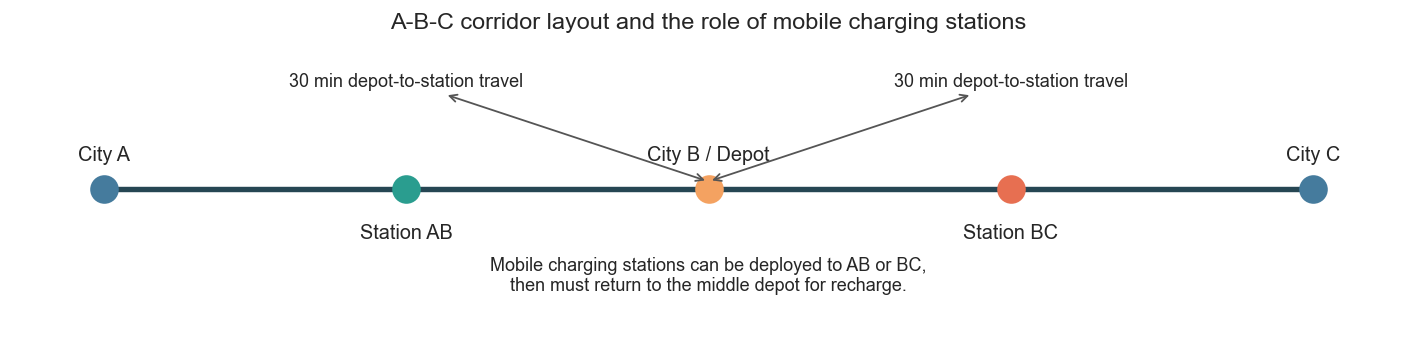

In [3]:
show_table(build_environment_overview_table(), precision=None)
fig, _ = plot_corridor_schematic()
plt.show()


The schematic highlights the key spatial constraint in the project. The depot is in the middle, while congestion may emerge on either side of the corridor. A controller therefore faces a real allocation problem: support sent to AB is not simultaneously available at BC, and vice versa.


## 3. Simulation design

This section explains how the simulator is built up step by step. The purpose is not to mimic every real-world detail, but to construct an operationally meaningful resilience testbed in which the control problem is interpretable.

### 3.1 Base corridor

The starting point is the simplest spatial setting that still has local congestion: three cities on a line and one fixed charging station on each link. This gives two service points, AB and BC, that can become stressed differently.

### 3.2 Time-varying demand

The next layer is demand variation over the day. Morning and evening peaks are added so that queue pressure is not constant. This matters because a resilience intervention should help most when traffic is concentrated, not only when the system is quiet.

### 3.3 OD structure

Demand is then split into origin-destination flows rather than a single generic arrival stream. That matters because some trips pressure only one station while long trips pressure both. The corridor therefore has directional structure, which is important for spatial allocation.

### 3.4 Queueing and service

Passing traffic is converted into charging demand. Some vehicles decide to stop, they join the queue of the relevant station, and they occupy a plug for a stochastic service time. This is the step that turns traffic variation into a service-level problem with waiting times.

### 3.5 Mobile charging stations

Mobile charging stations are added only after the fixed charging system exists. Their role is to add flexible capacity, not replace the fixed system. Introducing travel and recharge delays makes the MCS decision spatial and delayed rather than trivial.

### 3.6 Disruptions

Finally, disruption events are added. These reduce capacity, inflate service time, or create temporary demand surges. This is what turns the simulator into a resilience testbed rather than a normal-day capacity exercise.


| Layer added | Implementation | Why it matters |
| --- | --- | --- |
| Base corridor | Three cities in a line with one fixed station on each link. | Creates the minimal spatial setting in which local congestion can differ between AB and BC. |
| Time-varying demand | Morning peak, afternoon peak, and a smaller midday bump. | Makes congestion depend on time of day rather than a flat average flow. |
| OD structure | Trips are split across AB, BA, BC, CB, AC, and CA flows. | Allows station pressure to come from directional travel patterns, not only total volume. |
| Queueing and service | Vehicles may stop to charge, join queues, and occupy plugs for stochastic service times. | Turns traffic into an operational service problem with waiting-time consequences. |
| Mobile charging stations | Up to 10 MCS units add flexible but delayed capacity. | Creates the control lever that can potentially improve resilience. |
| Disruptions | Capacity drops, outages, service-time inflation, and OD demand surges. | Creates stress conditions under which resilience can be evaluated directly. |

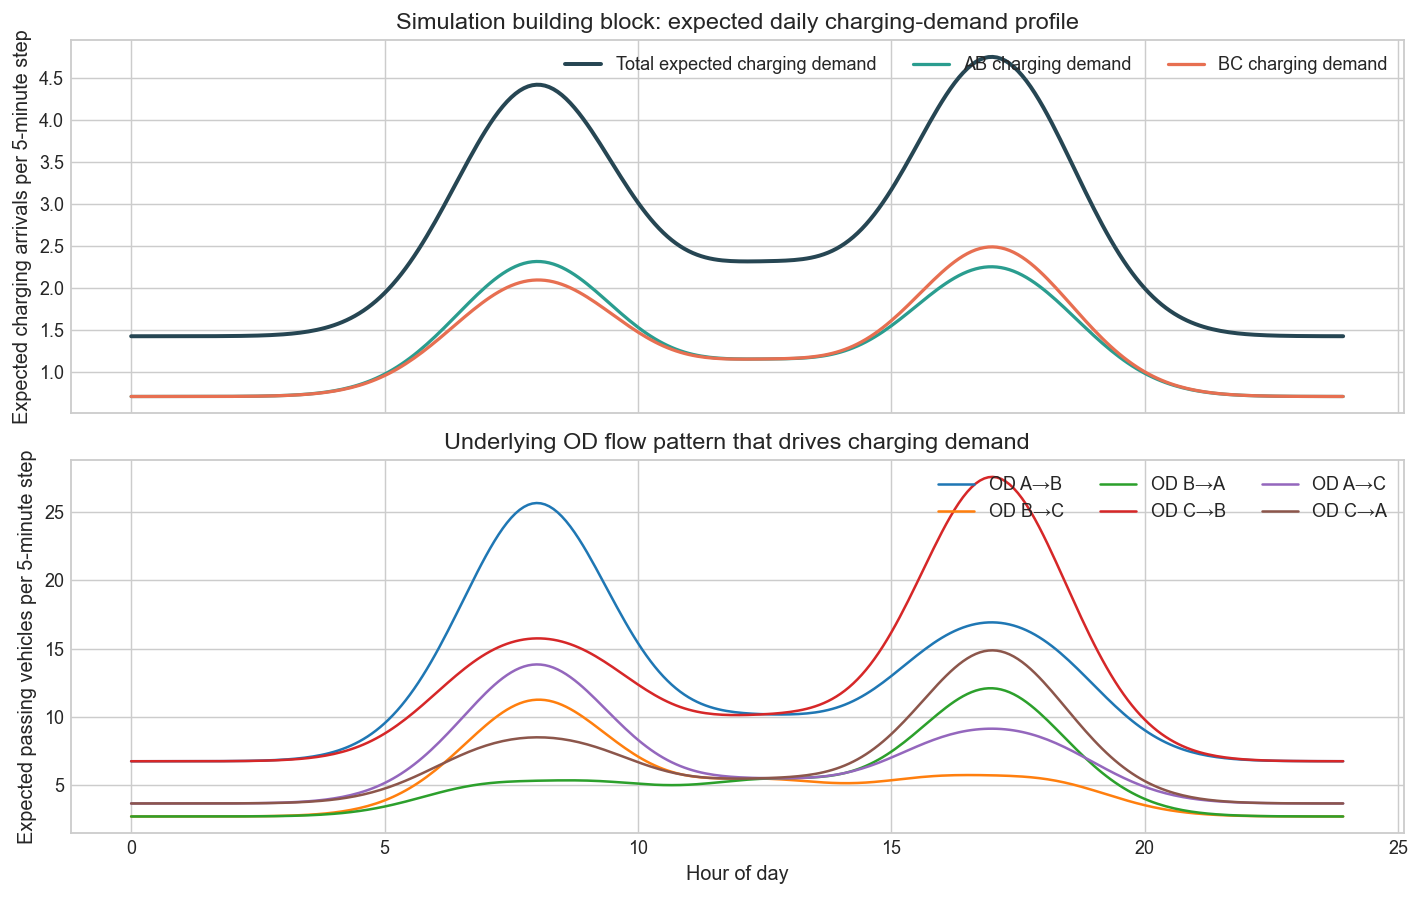

In [4]:
show_table(build_simulation_layers_table(), precision=None)
fig, _ = plot_demand_profile(daily_profile)
plt.show()


The demand plot is the first important building block. The top panel shows that expected charging demand is structured around a morning peak, an afternoon/evening peak, and a smaller midday bump. The lower panel shows the OD components that generate this pattern, which is why congestion can become directional rather than purely aggregate.


In [5]:
show_table(build_distribution_table(), precision=2)
show_table(build_disruption_table(), precision=None)


| Process | Distribution / mechanism | Assumption in the active benchmark |
| --- | --- | --- |
| Expected total traffic | Deterministic baseline + Gaussian-shaped morning/evening peaks + midday bump | Baseline 26 cars/step; peak width 1.6 h. |
| Origin shares | Time-varying weighted shares across A, B, and C origins | Directional bias shifts origin pressure toward A in the morning and toward C in the evening. |
| Passing vehicles by OD and step | Poisson draw around expected OD flow | Implements stochastic arrivals around the deterministic demand profile. |
| Charging decision | Binomial draw from passing vehicles with fixed stop probability | Charging-stop probability = 0.055. |
| Station assignment | Multinomial assignment using OD-specific station weights | Long trips can pressure both stations; local trips pressure one side only. |
| Service time | Normal draw, then clipped to configured min/max bounds | Mean 30 min, std 8, clipped to 15-50 min. |
| Disruptions per day | Categorical draw from configured day-level count weights | Weights: {0: 0.1, 1: 0.45, 2: 0.3, 3: 0.15}. |
| Disruption timing and severity | Uniform draws within configured ranges for start time, duration, and severity | Keeps disruptions stochastic but bounded and interpretable. |

| Type | Targets | Start window | Duration | Severity |
| --- | --- | --- | --- | --- |
| capacity drop | station_ab, station_bc | 6.0-20.0 h | [1.0, 3.5] | Target plugs sampled from [1, 5] |
| station outage | station_ab, station_bc | 6.0-21.0 h | [1.0, 2.5] | Target station forced to zero plugs |
| service time inflation | station_ab, station_bc | 6.0-20.0 h | [1.0, 3.5] | Service-time multiplier sampled from [1.5, 2.1] |
| demand surge | od_ab, od_ba, od_cb, od_bc, od_ac, od_ca | 6.0-20.0 h | [1.5, 4.5] | Demand multiplier sampled from [1.9, 2.9] |

Two design choices deserve emphasis.

First, the simulator mixes deterministic structure and stochastic realization. The daily demand profile is interpretable, but arrivals and service times are still random. Second, disruptions are sampled from bounded ranges. That keeps the scenarios diverse enough to test robustness, while still allowing the examiner to understand what a disruption actually means in this benchmark.


## 4. RL agent and methods

The repository contains two RL paths:

- a **simple PyTorch DQN / DQL path** that writes full train/eval diagnostics,
- an **SB3 DQN path** that is the intended stronger final policy path.

For the active benchmark, the action problem is deliberately posed as a **small directional control problem** rather than a large absolute-allocation table. The agent does not choose an arbitrary global allocation in one jump. Instead, it chooses whether to hold, push commitment toward AB or BC, or recall commitment from one side. This is easier to learn, easier to interpret, and more faithful to the operational story of gradual reallocation.

Because the current checkout does not contain a compatible final RL checkpoint, this report distinguishes between the **RL design** and the **reproducible final rollout evidence**. The RL design can still be described precisely and evaluated through training diagnostics.


In [6]:
show_table(build_architecture_table(), precision=None)
show_table(build_simple_hyperparameter_table(), precision=None)
show_table(build_sb3_hyperparameter_table(), precision=None)


| Item | Value |
| --- | --- |
| Observation size | 27 |
| Action size | 5 |
| Simple learner backend | torch_dqn |
| Simple learner network | MLP 27 → 256 → 256 → 5 |
| Simple learner optimizer | Adam, learning rate 0.0005 |
| Simple learner TD loss | Huber / smooth L1 loss on one-step TD targets |
| SB3 candidate backend | sb3_dqn |
| SB3 policy class | MlpPolicy with net_arch [256, 256] |
| Current checkpoint status | No current compatible checkpoint found in checkout |

| Simple learner hyperparameter | Value |
| --- | --- |
| Episodes | 130 |
| Max steps / episode | 1728 |
| Discount factor γ | 0.98 |
| Learning rate | 0.0005 |
| Batch size | 128 |
| Replay capacity | 200000 |
| Learning starts | 10000 |
| Train frequency | 4 |
| Gradient steps | 4 |
| Target update interval | 200 |
| Hidden dimensions | [256, 256] |
| Exploration start ε | 1.0 |
| Exploration end ε | 0.05 |
| Exploration decay steps | 125000 |
| Periodic eval cadence | Every 15000 environment steps |
| Periodic eval episodes | 10 |

| SB3 hyperparameter | Value |
| --- | --- |
| Total timesteps | 250000.0 |
| Learning rate | 0.0005 |
| Discount factor γ | 0.98 |
| Replay buffer | 200000.0 |
| Learning starts | 10000.0 |
| Batch size | 128.0 |
| Train frequency | 4.0 |
| Gradient steps | 1.0 |
| Exploration fraction | 0.5 |
| Initial ε | 1.0 |
| Final ε | 0.05 |
| Target update interval | 1000.0 |
| Evaluation episodes | 12.0 |

### State space

The observation is 27-dimensional. The model is given local queue pressure, recent flow, effective local capacity, mobile-station logistics, disruption indicators, and time-of-day information. This means the policy can react to where pressure is building, but it does **not** have perfect future knowledge.


In [7]:
show_table(build_state_group_table(), precision=None)
for item in WHAT_MODEL_DOES_NOT_KNOW:
    display(Markdown(f'- {item}'))


| Feature group | Count | Why it is in the state |
| --- | --- | --- |
| Queue state | 4 | Current queue length and current mean wait at AB and BC. |
| Recent flow | 4 | Latest arrivals and latest service starts at each station. |
| Capacity state | 4 | Effective plugs and active mobile capacity at AB and BC. |
| Spatial pressure | 4 | Committed MCS bias and local deficit estimates by side of corridor. |
| Disruption state | 4 | Whether a disruption is active, what type it is, and which side it affects. |
| MCS logistics | 5 | Units available in depot, charging, or in transit to AB, BC, or middle. |
| Time-of-day | 2 | Sine and cosine encodings of time within the day. |

- No exact future arrivals or exact future queue realizations.

- No oracle action labels or optimal allocation target.

- No foreknowledge of future random disruptions before they begin.

- No exact per-MCS battery state-of-charge representation.

- No direct remaining-disruption-time feature in the current observation.

- No explicit demand forecast beyond current local state and disruption indicators.

### Action space

The active action space has five commands: hold, move one unit toward AB, move one unit toward BC, recall one unit from AB, and recall one unit from BC. This should be read as a deliberate modeling choice, not a reduced convenience version. It keeps the controller focused on directional decisions that respect depot availability and relocation lag.

A subtle but important detail is that the environment itself decides whether a `toward_ab` command is satisfied from the middle depot or by shifting one committed unit from BC. The policy chooses the **directional intent**; the environment resolves the **physical logistics**.


In [8]:
show_table(action_table(), precision=None)


| Action | Interpretation |
| --- | --- |
| hold | Keep the committed mobile-station allocation unchanged. |
| toward_ab | Move one unit of commitment toward AB, either from depot or from BC. |
| toward_bc | Move one unit of commitment toward BC, either from depot or from AB. |
| recall_ab | Recall one committed unit away from AB toward the middle depot. |
| recall_bc | Recall one committed unit away from BC toward the middle depot. |

### Reward function and loss function

The reward combines service-quality incentives and operating-cost penalties.

The positive terms reward the agent for serving vehicles, using capacity productively, and placing mobile support where local deficits are estimated to be highest. The negative terms penalize queueing, waiting, unmet demand, unnecessary MCS activation, repeated adjustment, and carrying idle capacity.

This distinction matters because **operational performance** and **reward** are related but not identical. A policy may reduce queueing substantially while still earning a poor total reward if it uses too much costly mobile capacity.

The simple learner is trained with a **Huber TD loss** (`smooth_l1_loss`). Intuitively, the model predicts action values, compares them with one-step bootstrap targets, and updates the network to reduce that temporal-difference error. Huber loss is used because it is less brittle than pure squared error when RL targets are noisy.


In [9]:
positive_reward_table, negative_reward_table = build_reward_term_tables()
show_table(positive_reward_table, precision=2)
show_table(negative_reward_table, precision=2)


| Positive term | Weight | Operational role |
| --- | --- | --- |
| served_reward_weight | 1.0 | Rewards charging sessions that start service. |
| utilization_bonus | 1.0 | Rewards productive use of available charging capacity. |
| spatial_deficit_alignment_bonus | 24.0 | Rewards mobile capacity that covers estimated local deficits. |
| spatial_deficit_direction_bonus | 12.0 | Rewards sending MCS in the correct corridor direction. |

| Negative term | Weight | Operational role |
| --- | --- | --- |
| unmet_penalty | 2.5 | Penalizes vehicles left in queue after the step. |
| queue_length_penalty | 2.5 | Adds extra pressure against persistent queue accumulation. |
| queue_wait_penalty | 0.02 | Penalizes queue-wait burden, not just queue count. |
| local_queue_peak_penalty | 1.0 | Penalizes the worst station queue in the step. |
| local_wait_peak_penalty | 0.1 | Penalizes the worst station waiting time in the step. |
| active_mobile_station_cost | 18.0 | Charges for keeping MCS active in the field. |
| activation_cost | 2.0 | Charges for newly activating MCS. |
| adjustment_cost | 0.5 | Charges for reallocating MCS commitment. |
| idle_capacity_penalty | 0.1 | Penalizes carrying unused capacity. |

## 5. Reward calibration

Reward calibration is a core modeling choice in this project. Mobile charging can reduce queues, but it also represents operating cost. If the cost weight is too low, the controller may over-deploy MCS. If the queue penalty is too low, the controller may accept poor service rather than spend mobile capacity.

The historical reward sweep is useful here because it shows how changing these weights changes the learned operating point.


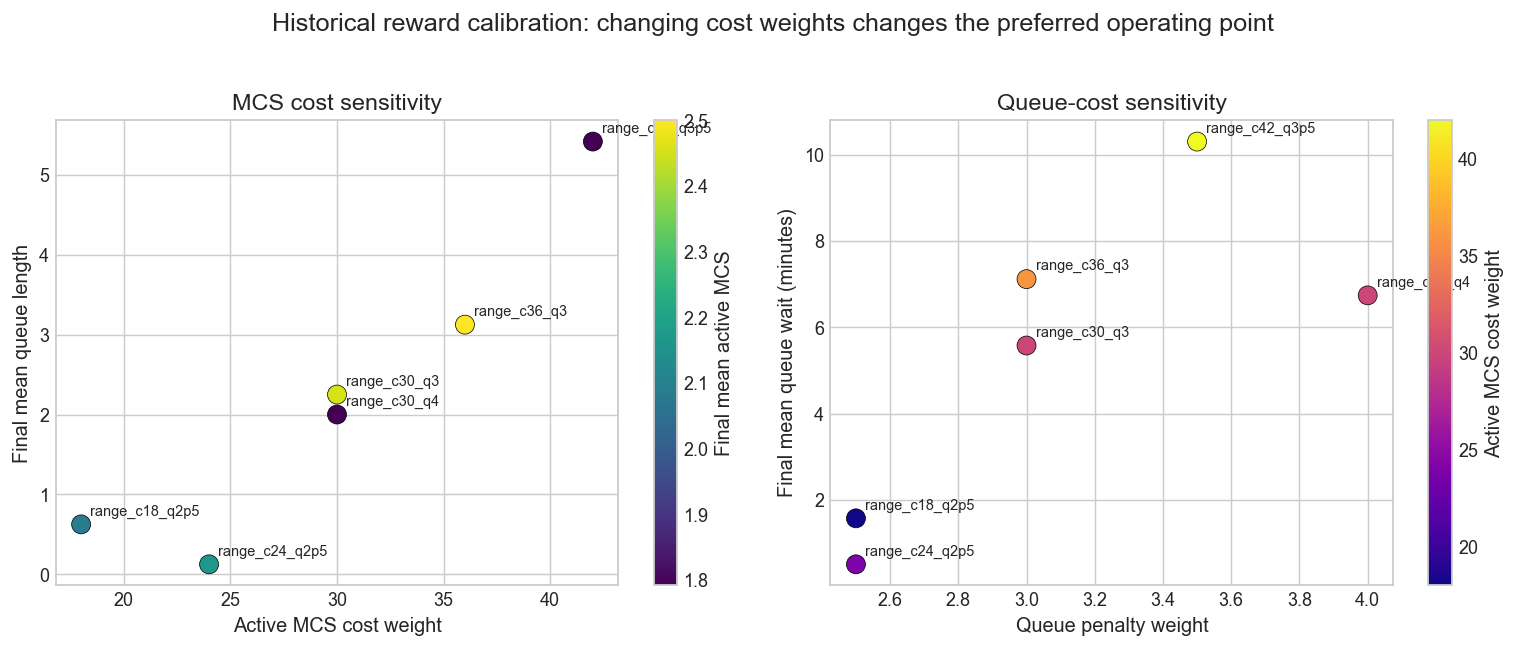

| Run | MCS cost | Queue cost | Mean queue | Mean wait | Mean active MCS | Final reward |
| --- | --- | --- | --- | --- | --- | --- |
| range_c18_q2p5 | 18.0 | 2.5 | 0.62 | 1.57 | 2.08 | -102.93 |
| range_c24_q2p5 | 24.0 | 2.5 | 0.12 | 0.5 | 2.17 | -146.77 |
| range_c30_q3 | 30.0 | 3.0 | 2.25 | 5.58 | 2.46 | -232.35 |
| range_c30_q4 | 30.0 | 4.0 | 2.0 | 6.74 | 1.79 | -199.99 |
| range_c36_q3 | 36.0 | 3.0 | 3.12 | 7.12 | 2.5 | -309.23 |
| range_c42_q3p5 | 42.0 | 3.5 | 5.42 | 10.31 | 1.79 | -305.46 |

In [10]:
fig, _ = plot_reward_sensitivity(reward_sweep)
plt.show()
show_table(build_reward_calibration_table(), precision=2)


The trade-off is clear. Higher MCS cost tends to push the policy toward lower MCS usage, but that usually comes with worse queue outcomes. Increasing queue penalties pushes the controller toward protecting service quality more aggressively. In other words, there is no single universally correct reward: the preferred policy depends on how expensive mobile support is assumed to be relative to poor queue performance.


## 6. Training setup

The training pipeline separates training episodes, periodic evaluation, held-out rollouts, and named stress scenarios.

- **Training** uses randomized episodes from the benchmark distribution.
- **Periodic evaluation** checks the current policy on held-out seeds without exploration and without learning updates.
- The **held-out rollout** is the final time-series comparison used in the main report.
- **Stress scenarios** are scripted one-day disruptions used as robustness checks and are kept in the appendix.

Even without hyperparameter tuning or early stopping, periodic evaluation is still useful. It shows whether the policy is improving on held-out scenarios rather than only fitting the randomness of the latest training episodes.


In [11]:
show_table(build_training_setup_table(), precision=None)


| Component | How it is used in this report |
| --- | --- |
| Training episodes | Randomized 2-6 day episodes sampled from training seeds 0-9999. |
| Periodic evaluation | 10 held-out episodes every 15000 environment steps without exploration or learning updates. |
| Validation split | Configured held-out validation seeds starting at 10000; useful for policy checks even without hyperparameter tuning. |
| Held-out rollout | A fixed unseen `test_id` scenario used for the main time-series comparison in this report. |
| Test stress suite | Named one-day scripted disruptions used for robustness checks; kept in the appendix to avoid clutter. |

## 7. Training the model

The final intended model path is SB3 DQN. However, the current repository snapshot does not contain a compatible checkpoint for the active benchmark, so the notebook cannot load and roll out that policy directly.

What **is** available is a copied current training-history artifact. That artifact contains train reward, train TD loss, evaluation reward, and evaluation TD loss. These diagnostics are therefore used as evidence about whether the RL learner improved during training.

The optional demo cell below is intentionally separate from the reported results. Its only purpose is to show how an examiner can launch a short local train/eval run using the included configs and reference code.


| Artifact check | Status |
| --- | --- |
| Training-history source | Copied current training history in exam_submission/data/generated/training/history_current.json |
| Train reward available | Yes |
| Train TD loss available | Yes |
| Eval reward available | Yes |
| Eval TD loss available | Yes |
| Current compatible checkpoint available | No |

| Checkpoint | Exists |
| --- | --- |
| No current compatible RL checkpoint found in the checkout | False |

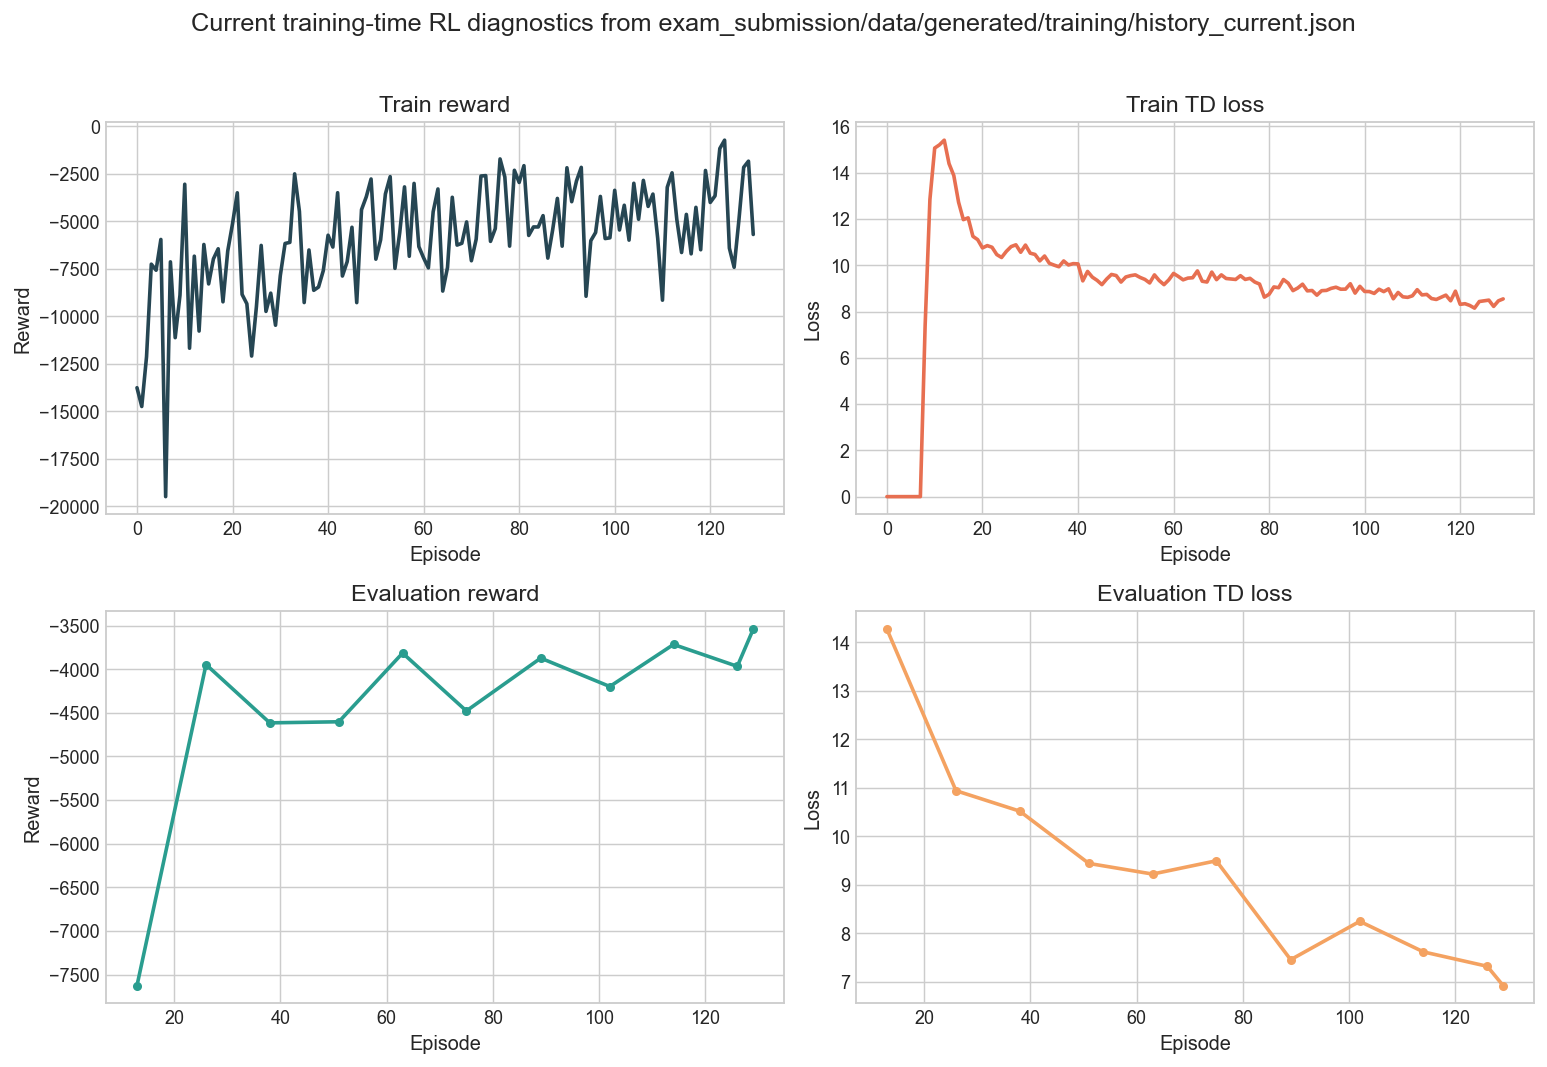

In [12]:
show_table(build_training_status_table(), precision=None)
show_table(build_checkpoint_status_table(), precision=None)
fig, _ = plot_training_history(training_history, source=training_history_source)
plt.show()


The learning curves should be interpreted carefully.

- Train reward and TD loss are noisy, as expected in RL.
- Evaluation reward is more informative than raw training reward because it is measured without exploration.
- Evaluation TD loss is not a supervised validation loss, but it is still useful as a consistency check on the learned value function.

The copied history suggests that the learner improved relative to its very poor early episodes and reached a more stable regime. However, because the compatible final checkpoint is missing, the report cannot make a final reproducible claim about RL rollout performance on the active benchmark.


In [13]:
RUN_DEMO_TRAINING = True

demo_command = [
    sys.executable,
    '-m',
    'evch.train.train_rl',
    '--config', str(REPO_ROOT / 'exam_submission/reference_code/configs/env/mobile_mcs_line_abc.yaml'),
    '--config', str(REPO_ROOT / 'exam_submission/reference_code/configs/demand/base.yaml'),
    '--config', str(REPO_ROOT / 'exam_submission/reference_code/configs/rl/dqn_mobile_simple.yaml'),
    '--config', str(REPO_ROOT / 'exam_submission/reference_code/configs/debug/logging_disabled.yaml'),
    '--config', str(REPO_ROOT / 'exam_submission/reference_code/configs/experiment/mobile_mcs_line_abc_train_only.yaml'),
    '--config', str(REPO_ROOT / 'exam_submission/reference_code/configs/demo/mobile_mcs_line_abc_demo_short.yaml'),
]

if RUN_DEMO_TRAINING:
    env = os.environ.copy()
    env['PYTHONPATH'] = str(REPO_ROOT / 'src') + os.pathsep + env.get('PYTHONPATH', '')
    completed = subprocess.run(
        demo_command,
        cwd=REPO_ROOT,
        env=env,
        timeout=300,
        capture_output=True,
        text=True,
        check=True,
    )
    display(Markdown('### Demo run output\n\n```text\n' + completed.stdout[-4000:] + '\n```'))
else:
    display(Markdown(
        '### Optional demo run\n\n'
        'The demo run is disabled by default so the notebook stays fast and deterministic. '
        'To run a short local train/eval demonstration, set `RUN_DEMO_TRAINING = True` in this cell.\n\n'
        '```bash\n' + ' '.join(demo_command) + '\n```'
    ))


### Demo run output

```text

```

## 8. Simulation comparison rollout

The intended main comparison was fixed-only capacity versus the final RL controller. Because no current-compatible RL rollout artifact is present in the checkout, that exact comparison cannot be reproduced honestly in this notebook.

To keep the report reproducible, the main operational comparison below uses:

- the **fixed / no-agent baseline**, and
- the **adaptive threshold controller**, which is the strongest current adaptive rollout artifact available.

This still answers an important resilience question: does adaptive mobile support materially reduce queueing pressure relative to doing nothing adaptive at all? The appendix retains the reactive rule as secondary context, but it is removed from the main section to keep the story clean.


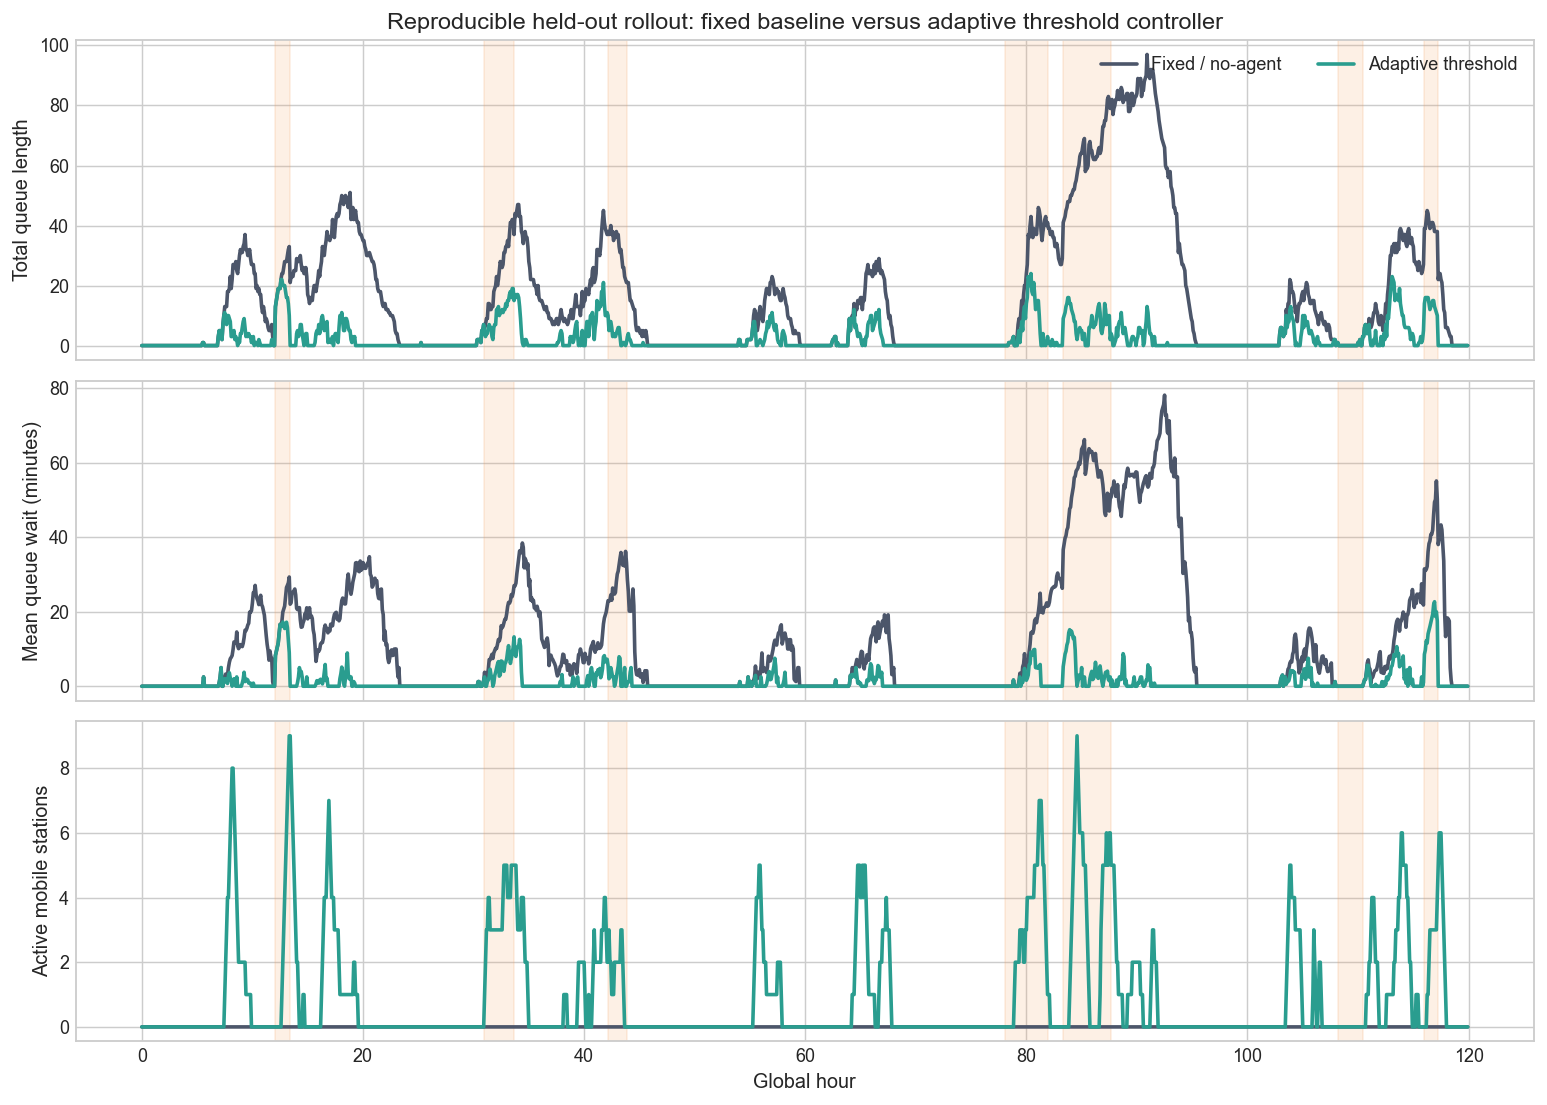

In [14]:
main_frames = {name: heldout_frames[name] for name in MAIN_POLICIES}
fig, _ = plot_main_rollout_comparison(main_frames)
plt.show()


The held-out rollout shows a clear operational improvement. Fixed capacity alone allows queue length and waiting time to build up substantially during disruption windows. The adaptive threshold controller responds by activating mobile support, which reduces both total queueing and average waiting time.

The plot also illustrates the cost side of the problem: queue improvement is achieved by using MCS, not by creating capacity from nowhere. That is why the reward section and the reward-calibration section matter for interpretation.


## 9. Summary metrics table

The table below summarizes the held-out rollout used in the main comparison. Breach-rate columns are shown for completeness, but they are not informative in the active exported artifacts because the queue-wait target is zero throughout the rollout files.


In [15]:
show_table(build_main_results_table(), precision=2)


| Policy | Mean queue | Peak queue | Mean wait (min) | Peak wait (min) | Breach rate | Started sessions | Mean active MCS | MCS hours | Reward | Queue improvement vs fixed (%) | Wait improvement vs fixed (%) | Reward change vs fixed |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| Fixed / no-agent | 16.6 | 97.0 | 12.37 | 78.14 | 0.0 | 3851.0 | 0.0 | 0.0 | -15969.37 | 0.0 | 0.0 | 0.0 |
| Adaptive threshold | 2.65 | 24.0 | 1.28 | 22.69 | 0.0 | 3846.0 | 0.95 | 113.5 | -4202.84 | 84.06 | 89.62 | 11766.53 |

The key result is that adaptive mobile support meaningfully reduces queueing pain relative to fixed-only operation. The threshold controller improves service outcomes while using much less mobile support than the more aggressive reactive rule shown later in the appendix. That makes it the cleanest main comparator among the currently reproducible adaptive artifacts.


## 10. Spatial awareness

A spatially aware controller should allocate support where local pressure is highest. In this corridor, that means MCS at AB should increase when AB has higher local demand or queue pressure, while MCS at BC should increase when BC is more stressed.

The threshold controller is the clearest current artifact for checking this. The plots below show one-hour rolling averages of expected station demand, local queue length, and MCS allocation for AB and BC separately.


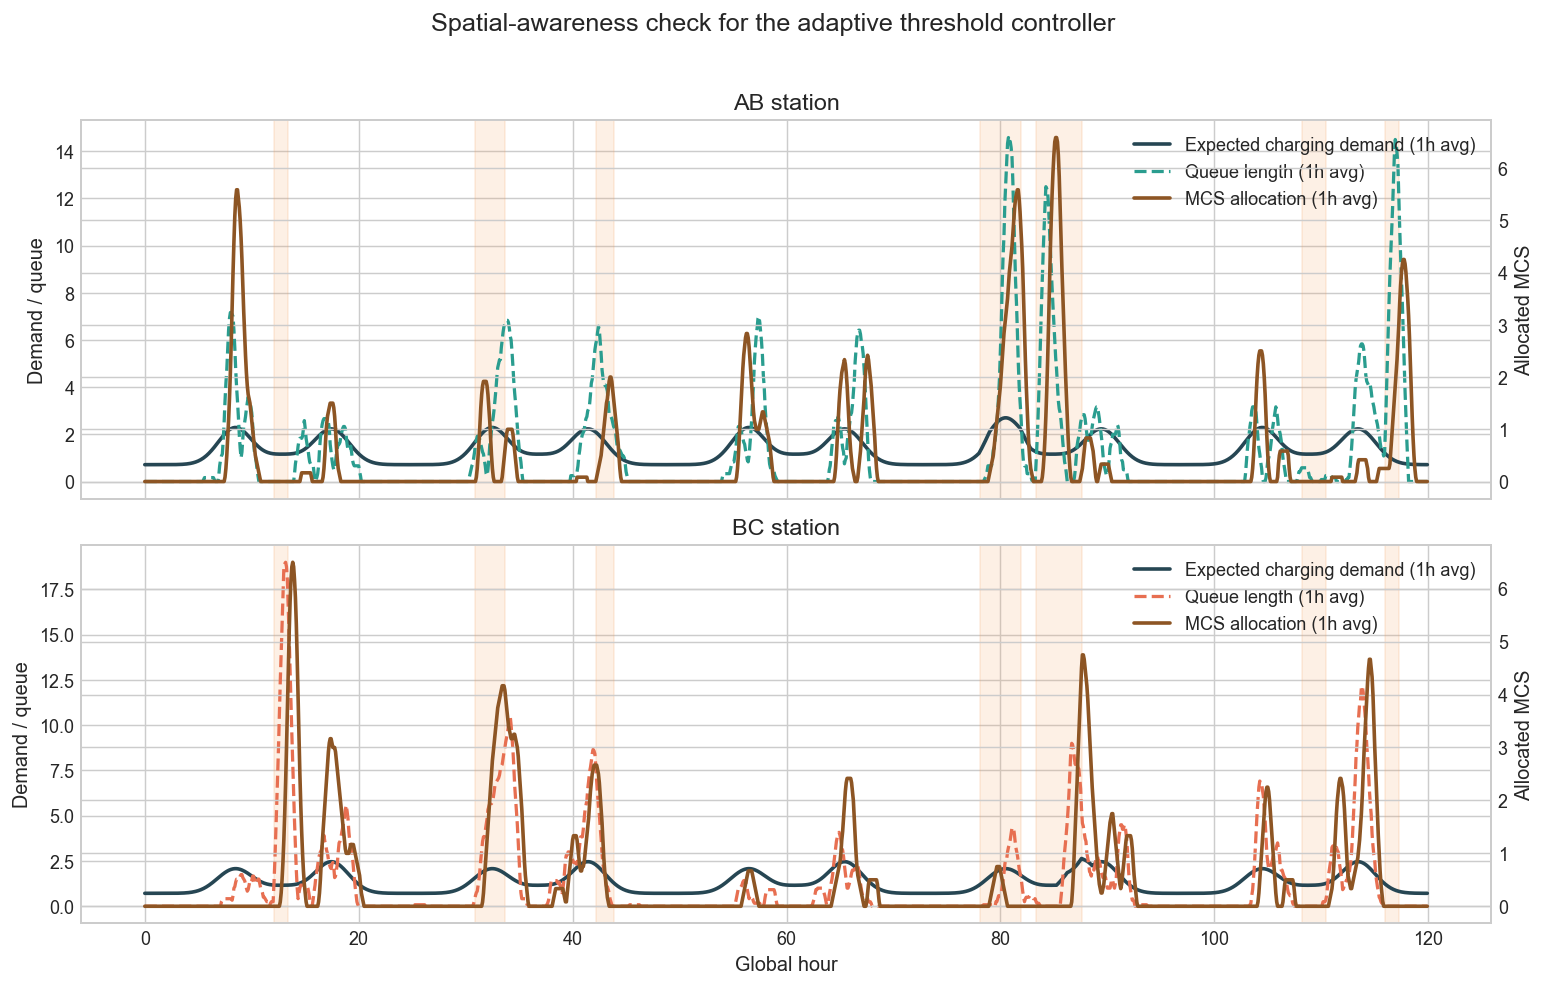

In [16]:
fig, _ = plot_spatial_station_overlays(heldout_frames['mobile_threshold'], rolling_steps=12)
plt.show()


The spatial response is meaningful but not perfect.

- When local pressure rises, MCS allocation generally rises on the same side of the corridor.
- The response is not instantaneous, which is expected because MCS units must travel and recharge.
- The relationship is clearer for the threshold controller than for the reactive rule, because the reactive policy tends to keep many units active system-wide rather than expressing a clean directional response.

So the appropriate claim is not “perfect spatial awareness”. A more defensible conclusion is that the current simulator can reveal spatial behavior clearly, and the adaptive threshold artifact shows a visible directional response to local service pressure.


## 11. Limitations

Several limitations are important and should be stated directly.

1. **The simulator is synthetic.** It is designed to be operationally meaningful, but it is not a calibrated production model of a real EV corridor.
2. **The current checkout lacks a compatible RL checkpoint.** The RL formulation and training diagnostics are available, but a final reproducible RL-vs-baseline rollout claim cannot be made from this repository snapshot alone.
3. **Reward sensitivity is substantial.** Different cost weights can change the preferred behavior significantly, especially the willingness to keep MCS active.
4. **Spatial behavior is partial rather than perfect.** Travel delay, recharge delay, directional symmetry, and cost all weaken one-to-one alignment between local pressure and instantaneous allocation.
5. **Logistics are simplified.** The simulator captures relocation and recharge delays, but not the full operational complexity of staffing, road-network uncertainty, or battery degradation.
6. **Stress coverage is limited.** The appendix shows several scripted stress scenarios, but this is still a bounded test set rather than a full uncertainty analysis over all possible disruptions.

These limitations do not invalidate the project, but they do constrain what can be claimed. The report therefore focuses on what is actually supported by the copied artifacts.


## 12. Conclusion

The project builds a coherent simulator for resilience in EV charging under disruption on a simple but informative A-B-C corridor. The environment combines time-varying demand, OD structure, queueing, service dynamics, mobile charging logistics, and several disruption types in a way that is interpretable from top to bottom.

Within the **current reproducible artifacts**, adaptive mobile support clearly improves service outcomes relative to fixed-only operation. The threshold controller reduces mean and peak queueing while using a moderate amount of mobile support. The RL formulation itself is well specified, and the copied train/eval curves suggest learning progress, but the absence of a compatible current RL checkpoint prevents a final reproducible RL rollout claim.

The most defensible final takeaway is therefore twofold: the simulator is strong enough to study resilience and spatial allocation, and adaptive mobile charging has clear value in that simulator. The next concrete step would be to recover or retrain a current-compatible RL checkpoint and benchmark it directly against the threshold baseline documented here.


## 13. Appendix

The appendix keeps secondary material out of the main narrative while still documenting the broader evidence base used in the project.


### A. Full 27-feature observation table


In [17]:
show_table(build_observation_appendix_table(), precision=None)


| Group | Idx | Feature | Meaning |
| --- | --- | --- | --- |
| Queue state | 1 | queue_length_ab | Current queue length at station AB. |
| Queue state | 2 | queue_length_bc | Current queue length at station BC. |
| Queue state | 3 | mean_queue_wait_ab | Mean current waiting time in the AB queue. |
| Queue state | 4 | mean_queue_wait_bc | Mean current waiting time in the BC queue. |
| Recent flow | 5 | last_arrivals_ab | Vehicles that arrived to AB in the last step. |
| Recent flow | 6 | last_arrivals_bc | Vehicles that arrived to BC in the last step. |
| Recent flow | 7 | last_starts_ab | Charging sessions started at AB in the last step. |
| Recent flow | 8 | last_starts_bc | Charging sessions started at BC in the last step. |
| Capacity | 9 | effective_plugs_ab | Effective plugs at AB after disruption and MCS effects. |
| Capacity | 10 | effective_plugs_bc | Effective plugs at BC after disruption and MCS effects. |
| Capacity | 11 | active_mobile_capacity_ab | Currently active mobile-station capacity at AB. |
| Capacity | 12 | active_mobile_capacity_bc | Currently active mobile-station capacity at BC. |
| Spatial | 13 | committed_mcs_bias_ab_minus_bc | Committed MCS bias toward AB versus BC. |
| Spatial | 14 | local_deficit_ab | Local deficit estimate at AB. |
| Spatial | 15 | local_deficit_bc | Local deficit estimate at BC. |
| Spatial | 16 | local_deficit_bias_ab_minus_bc | Local deficit bias toward AB versus BC. |
| Disruption | 17 | disruption_active | Whether a disruption is currently active. |
| Disruption | 18 | disruption_type_code | Encoded disruption type. |
| Disruption | 19 | target_affects_ab | Whether the disruption affects AB. |
| Disruption | 20 | target_affects_bc | Whether the disruption affects BC. |
| MCS logistics | 21 | middle_available | Mobile stations available at the middle depot. |
| MCS logistics | 22 | middle_charging | Mobile stations currently recharging at the middle depot. |
| MCS logistics | 23 | transit_to_ab | Mobile stations moving toward AB. |
| MCS logistics | 24 | transit_to_bc | Mobile stations moving toward BC. |
| MCS logistics | 25 | transit_to_middle | Mobile stations returning to the middle depot. |
| Time | 26 | sin_time_of_day | Sine encoding of time of day. |
| Time | 27 | cos_time_of_day | Cosine encoding of time of day. |